# Ionospheric Scintillation Analyzer -- Usage Example

Full pipeline: load PM6 data, clean signal, bandpass filter, CWT spectrogram.

Uses the `core/` modules of the analyzer.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, ".")

from core.parsers import load_pm6_data, parse_regi_with_time, build_observation_sessions
from core.signal_processing import clean_and_smooth_signal, compute_cwt_spectrogram
from core.config import DEFAULT_WINDOW_SIZE, DEFAULT_N_SIGMAS, CWT_NV, PCHIP_FACTOR
from scipy.signal import butter, sosfiltfilt

plt.rcParams.update({"figure.dpi": 120})

## 1. Load PM6 Data
Set `PM6_FILE` to your `.pm6` file path.

In [2]:
PM6_FILE = "data/04012013me.PM6"
CHANNEL  = "P1_20A"                 # receiver channel

df = load_pm6_data(PM6_FILE)
fs = 1.0
start_dt = df['Datetime'].iloc[0]
n = len(df)
print(f"Loaded {n} samples  |  fs={fs} Hz  |  Start: {start_dt}")
df.head()

Loaded 506069 samples  |  fs=1.0 Hz  |  Start: 2013-01-04 17:48:48.240000155


,MJD,P1_20A,M1_20A,P2_20B,M2_20B,P3_25A,M3_25A,P4_25B,M4_25B,Datetime,Time_sec,20 MHz Pol A (P-M),20 MHz Pol B (P-M),25 MHz Pol A (P-M),25 MHz Pol B (P-M)
0,41278.742225,6.708,6.645,17.01,16.90,8.021,7.960,8.112,8.188,2013-01-04 17:48:48.240000155,0.0,0.063,0.11,0.061,-0.076
1,41278.742238,6.649,6.611,17.01,16.89,8.006,7.942,8.134,8.126,2013-01-04 17:48:49.363199904,1.0,0.038,0.12,0.064,0.008
2,41278.742251,6.631,6.593,16.94,16.92,7.991,7.982,8.102,8.062,2013-01-04 17:48:50.486400285,2.0,0.038,0.02,0.009,0.040
3,41278.742263,6.589,6.656,16.97,16.94,7.981,7.994,8.085,8.096,2013-01-04 17:48:51.523200008,3.0,-0.067,0.03,-0.013,-0.011
4,41278.742276,6.605,6.647,16.86,16.97,7.939,8.014,8.079,8.089,2013-01-04 17:48:52.646399758,4.0,-0.042,-0.11,-0.075,-0.010


## 2. Parse Observation Sessions from REGI Log

In [3]:
REGI_FILE = "data/regi4-1-2013.txt"

events   = parse_regi_with_time(REGI_FILE, start_dt)
df_logs, calibrations, sessions = build_observation_sessions(events, df["Time_sec"].max())

for s in sessions:
    dur = (s["end"] - s["start"]) / 60
    tgt = s["target"]
    print(f"{tgt:20s}  {dur:.1f} min")

3C461                 197.0 min
3C144                 337.0 min
3C274                 381.0 min
3C100                 21.0 min
3C461                 197.0 min
3C144                 337.0 min
3C274                 381.0 min
3C100                 21.0 min
3C461                 197.0 min
3C144                 337.0 min
3C274                 381.0 min
3C100                 21.0 min
3C461                 197.0 min
3C144                 337.0 min
3C274                 381.0 min
3C100                 21.0 min
3C461                 197.0 min
3C144                 337.0 min
3C274                 381.0 min
3C100                 21.0 min
3C461                 197.0 min
3C144                 337.0 min
3C274                 381.0 min
3C100                 21.0 min
3C461                 197.0 min
3C144                 337.0 min
3C274                 381.0 min
3C100                 21.0 min


## 3. Clean Signal and Bandpass Filter
Hampel outlier removal + Savitzky-Golay smoothing, then a Butterworth bandpass.

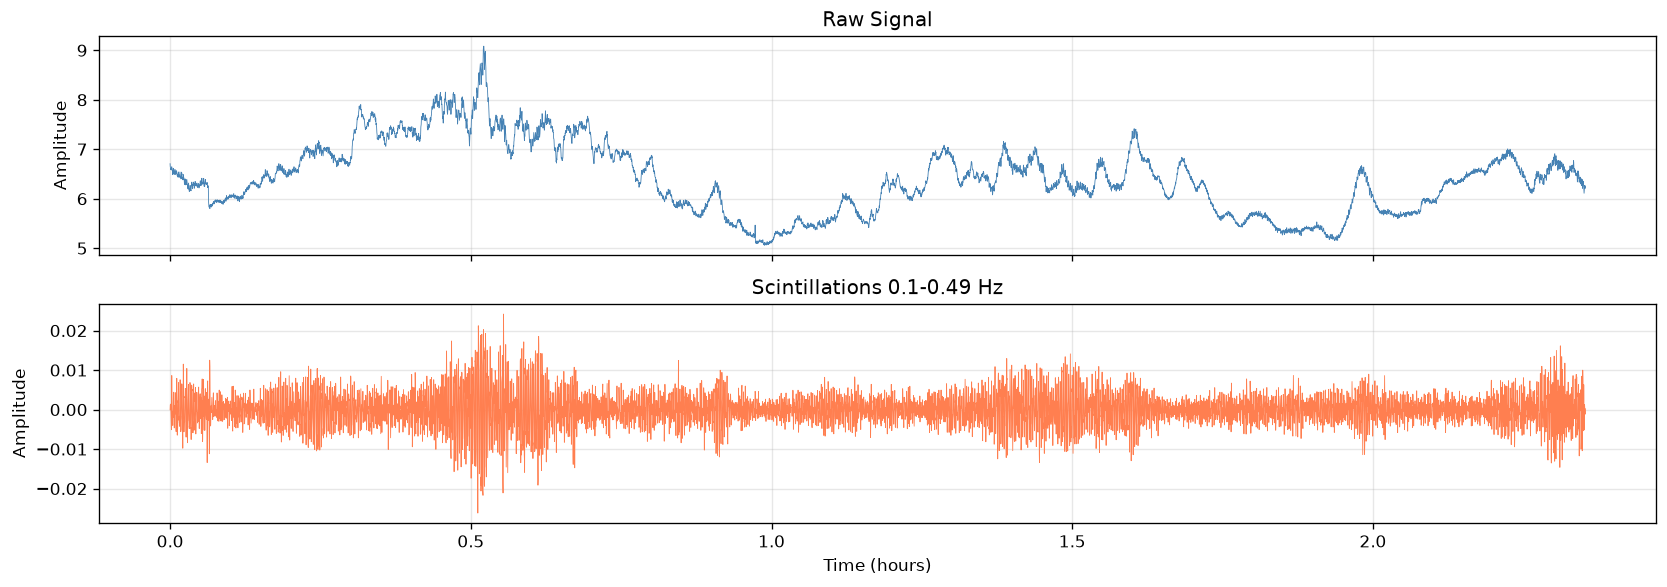

In [4]:
# Select one session (change index for a different source transit)
session = sessions[0]
s_idx = int(df["Time_sec"].searchsorted(session["start"]))
e_idx = int(df["Time_sec"].searchsorted(session["end"]))
time_s = df["Time_sec"].values[s_idx:e_idx]
signal = df[CHANNEL].values[s_idx:e_idx]

cleaned = clean_and_smooth_signal(signal, DEFAULT_WINDOW_SIZE, DEFAULT_N_SIGMAS)

LOWCUT, HIGHCUT = 0.1, 0.49  # Hz
sos = butter(4, [LOWCUT, HIGHCUT], btype="bandpass", fs=fs, output="sos")
scintillations = sosfiltfilt(sos, cleaned)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(time_s/3600, signal,         color="steelblue", lw=0.5)
axes[0].set(ylabel="Amplitude", title="Raw Signal"); axes[0].grid(alpha=0.3)
axes[1].plot(time_s/3600, scintillations, color="coral",     lw=0.5)
label = "Scintillations " + str(LOWCUT) + "-" + str(HIGHCUT) + " Hz"
axes[1].set(ylabel="Amplitude", title=label); axes[1].grid(alpha=0.3)
axes[-1].set_xlabel("Time (hours)")
plt.tight_layout(); plt.show()

## 4. CWT Spectrogram
Generalized Morse Wavelet with Synchrosqueezing for sharp frequency localisation.

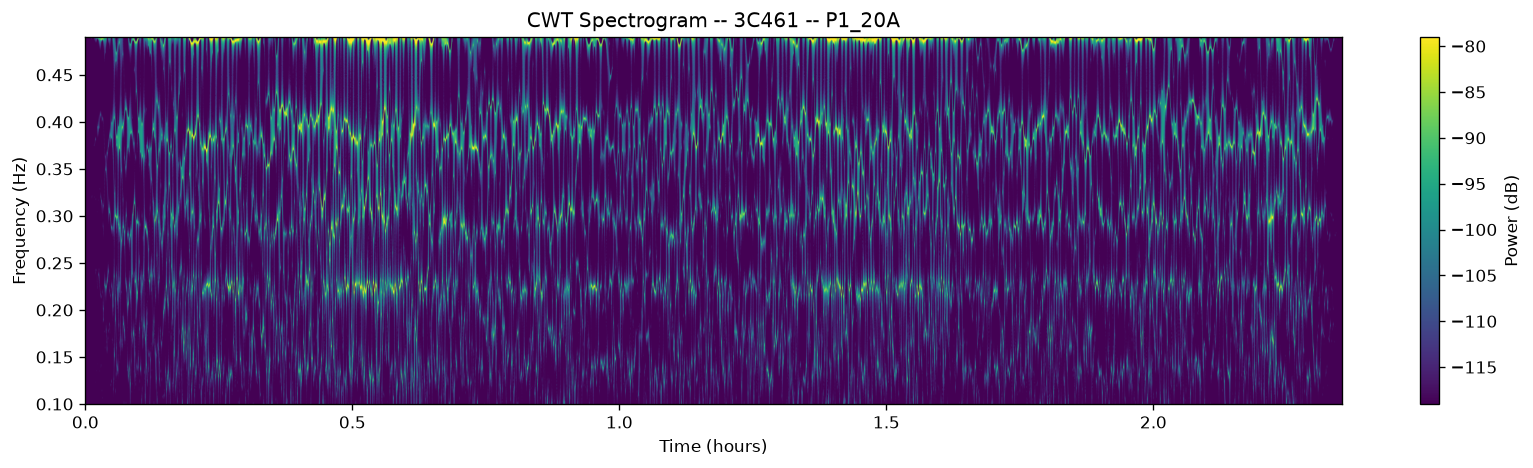

Spectrogram shape: (8472, 603) (time x frequency)


In [5]:
from scipy.interpolate import pchip_interpolate

# Upsample before CWT for better frequency resolution
new_fs = fs * PCHIP_FACTOR
t_up   = np.linspace(time_s[0], time_s[-1], len(time_s) * PCHIP_FACTOR)
sig_up = pchip_interpolate(time_s, scintillations, t_up)

spec = compute_cwt_spectrogram(
    sig_up, fs=new_fs, lowcut=LOWCUT, highcut=HIGHCUT,
    nv=CWT_NV, use_ssq=True  # use_ssq=False for very long signals (>14 h)
)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(spec.T, aspect="auto", origin="lower",
               extent=[time_s[0]/3600, time_s[-1]/3600, LOWCUT, HIGHCUT],
               cmap="viridis")
plt.colorbar(im, ax=ax, label="Power (dB)")
tgt = session["target"]
ax.set(xlabel="Time (hours)", ylabel="Frequency (Hz)",
       title=f"CWT Spectrogram -- {tgt} -- {CHANNEL}")
plt.tight_layout(); plt.show()
print("Spectrogram shape:", spec.shape, "(time x frequency)")

## Notes
- Run the full interactive GUI with: `uv run app.py`  
- Hyperparameters live in `core/config.py` and are editable live in the Settings dialog.  
- `use_ssq=True` gives sharp spectrograms on short signals via Synchrosqueezing.  
- Use `use_ssq=False` for very long signals (> 14 h) to avoid memory issues.